In [1]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Input, Dense, Reshape, Flatten, Dropout, Conv2DTranspose,
    BatchNormalization, Activation, ZeroPadding2D, LeakyReLU,
    UpSampling2D, Conv2D
)

import matplotlib.pyplot as plt
import sys

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("X_train shape:", X_train.shape)   # expect (50000, 32, 32, 3)
print("y_train shape:", y_train.shape)   # expect (50000, 1)
print("X_test  shape:", X_test.shape)    # expect (10000, 32, 32, 3)
print("dtype:", X_train.dtype)
print("pixel value range: min =", X_train.min(), ", max =", X_train.max())

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test  shape: (10000, 32, 32, 3)
dtype: uint8
pixel value range: min = 0 , max = 255


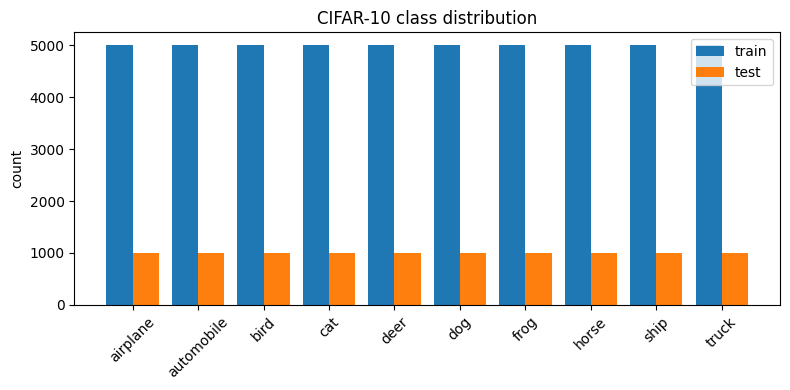

In [4]:
train_counts = np.bincount(y_train.squeeze())
test_counts = np.bincount(y_test.squeeze())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(10)
ax.bar(x - 0.2, train_counts, width=0.4, label='train')
ax.bar(x + 0.2, test_counts, width=0.4, label='test')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel("count")
ax.set_title("CIFAR-10 class distribution")
ax.legend()
plt.tight_layout()
plt.show()

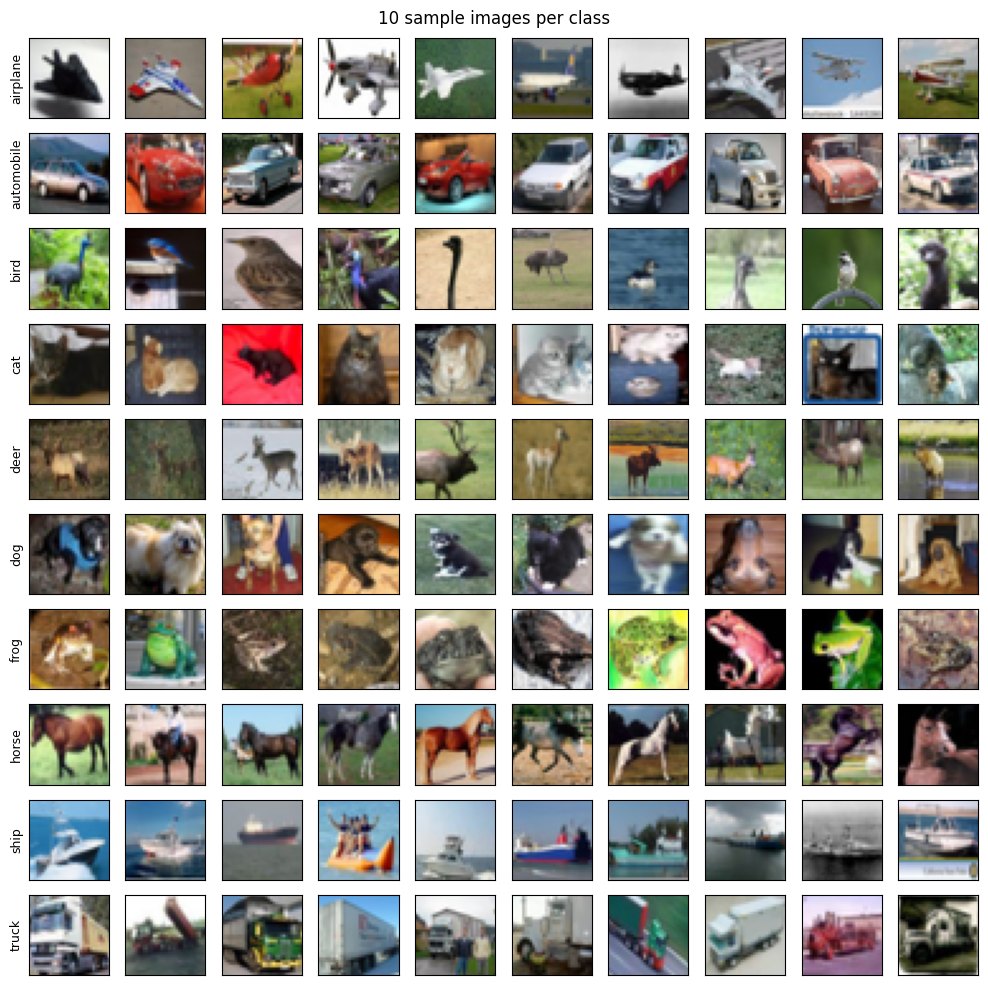

In [5]:
y_train_flat = y_train.squeeze()

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for class_idx in range(10):
    class_images = X_train[y_train_flat == class_idx]
    for i in range(10):
        ax = axes[class_idx, i]
        ax.imshow(class_images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9)

plt.suptitle("10 sample images per class")
plt.tight_layout()
plt.show()

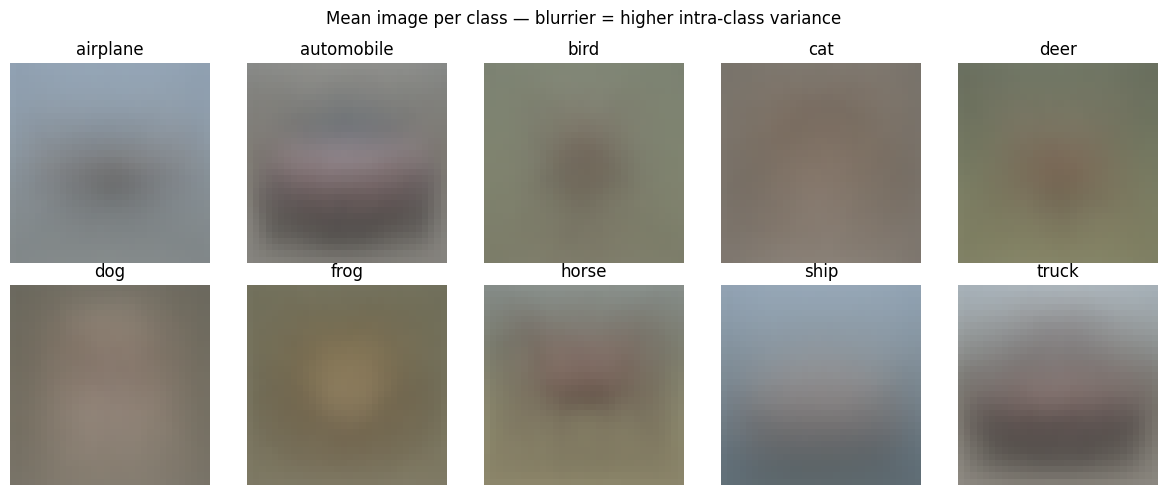

In [6]:
X_train_norm = X_train.astype("float32") / 255.0
y_train_flat = y_train.squeeze()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_idx in range(10):
    class_images = X_train_norm[y_train_flat == class_idx]
    mean_img = class_images.mean(axis=0)
    ax = axes[class_idx // 5, class_idx % 5]
    ax.imshow(mean_img)
    ax.set_title(class_names[class_idx])
    ax.axis('off')

plt.suptitle("Mean image per class — blurrier = higher intra-class variance")
plt.tight_layout()
plt.show()

eda end


In [7]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding an image."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
latent_dim = 64

encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 16, 16, 32)   896         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d[0][0]']                 
                                                                                                  
 conv2d_2 (Conv2D)              (None, 4, 4, 128)    73856       ['conv2d_1[0][0]']               
                                                                                            

In [9]:
decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(4 * 4 * 128, activation="relu")(decoder_inputs)
x = layers.Reshape((4, 4, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64)]              0         
                                                                 
 dense_1 (Dense)             (None, 2048)              133120    
                                                                 
 reshape (Reshape)           (None, 4, 4, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 8, 8, 128)        147584    
 nspose)                                                         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 16, 16, 64)       73792     
 ranspose)                                                       
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 32, 32, 32)       1846

In [10]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [11]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

checkpoint_path = "cvae_cifar10_best.weights.h5"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint_cb]
)

Epoch 1/100
391/391 [==============================] - ETA: 0s - loss: 684.5873 - reconstruction_loss: 659.1446 - kl_loss: 7.4019
Epoch 1: loss improved from inf to 666.54633, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 16s 18ms/step - loss: 684.5413 - reconstruction_loss: 659.1446 - kl_loss: 7.4019
Epoch 2/100
389/391 [============================>.] - ETA: 0s - loss: 644.7694 - reconstruction_loss: 630.9750 - kl_loss: 11.2983
Epoch 2: loss improved from 666.54633 to 642.27362, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 6s 15ms/step - loss: 644.7503 - reconstruction_loss: 630.9739 - kl_loss: 11.2997
Epoch 3/100
388/391 [============================>.] - ETA: 0s - loss: 637.3302 - reconstruction_loss: 623.4157 - kl_loss: 12.5023
Epoch 3: loss improved from 642.27362 to 635.92053, saving model to cvae_cifar10_best.weights.h5
391/391 [==============================] - 6s 15ms/step - loss: 637.3157 - 

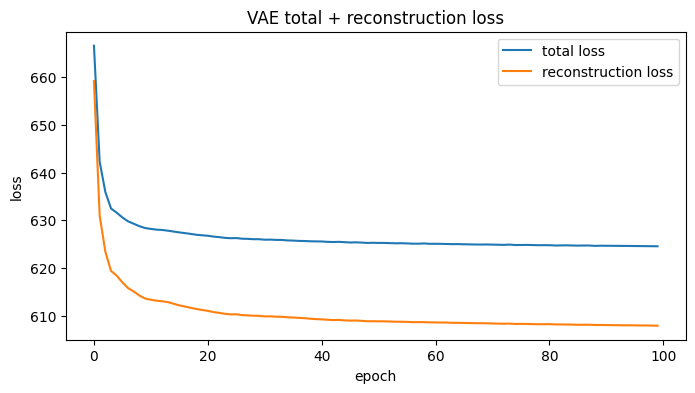

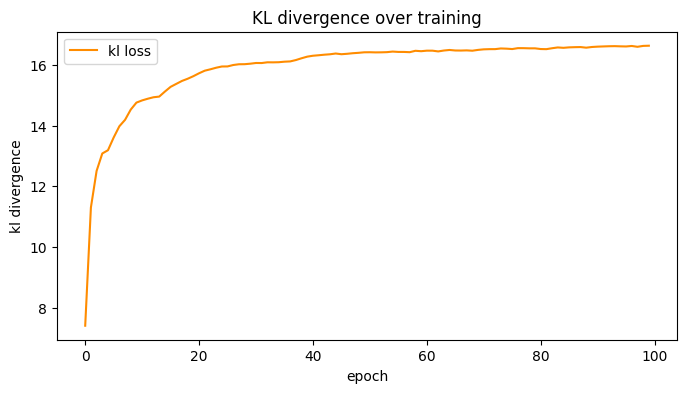

Final total loss: 624.5532
Final reconstruction loss: 607.9202
Final KL divergence: 16.6329


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='total loss')
plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('VAE total + reconstruction loss')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['kl_loss'], label='kl loss', color='darkorange')
plt.xlabel('epoch')
plt.ylabel('kl divergence')
plt.legend()
plt.title('KL divergence over training')
plt.show()
final_loss = history.history['loss'][-1]
final_recon_loss = history.history['reconstruction_loss'][-1]
final_kl_loss = history.history['kl_loss'][-1]

print(f"Final total loss: {final_loss:.4f}")
print(f"Final reconstruction loss: {final_recon_loss:.4f}")
print(f"Final KL divergence: {final_kl_loss:.4f}")

1/1 [==============================] - 0s 124ms/step


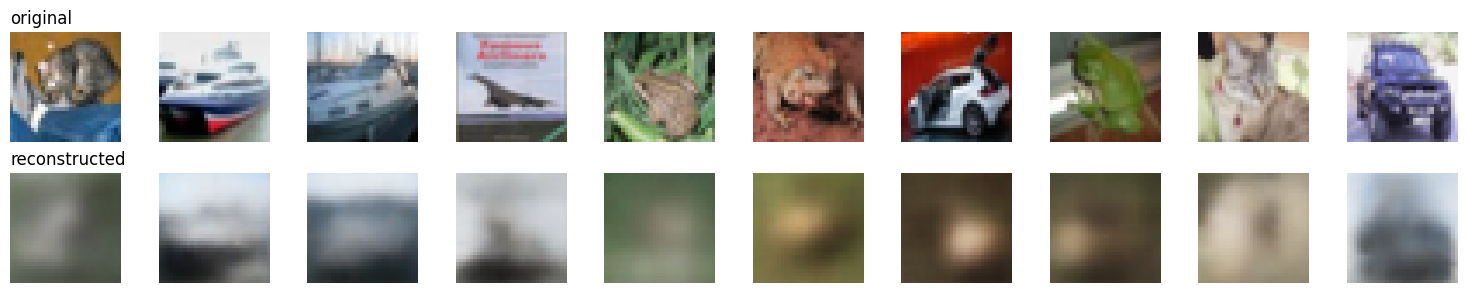

In [13]:
n = 10
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs)
reconstructed = vae.decoder.predict(z)

fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()


Training latent_dim=16
Final -> total: 624.9308, recon: 610.3189, kl: 14.6119


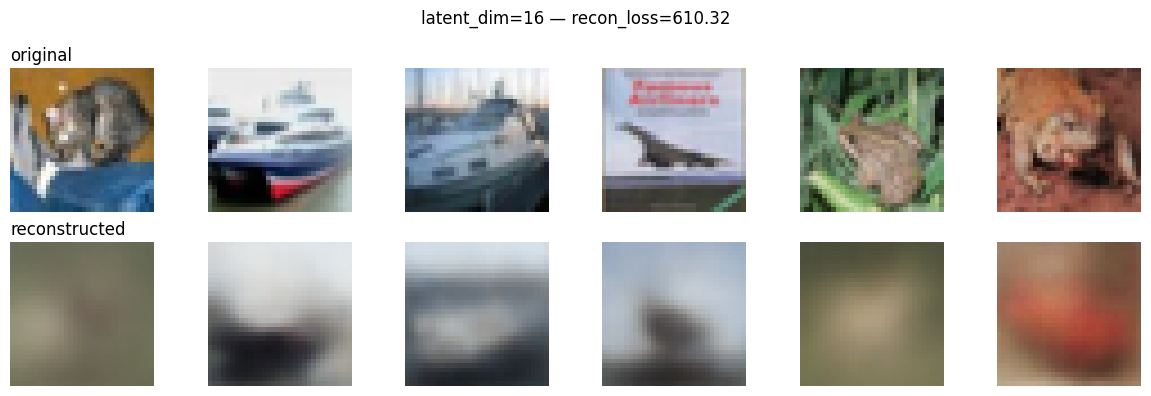


Training latent_dim=32
Final -> total: 624.4595, recon: 609.6094, kl: 14.8500


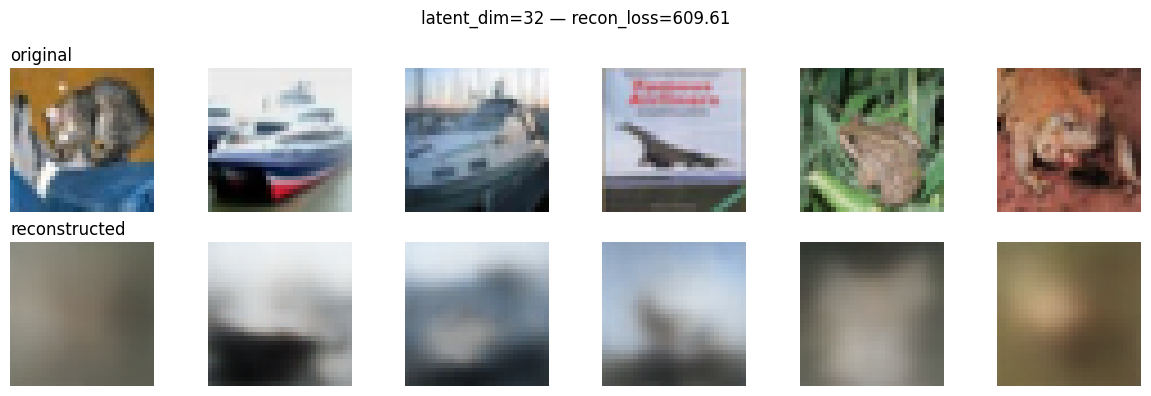


Training latent_dim=64
Final -> total: 625.4410, recon: 611.1887, kl: 14.2521


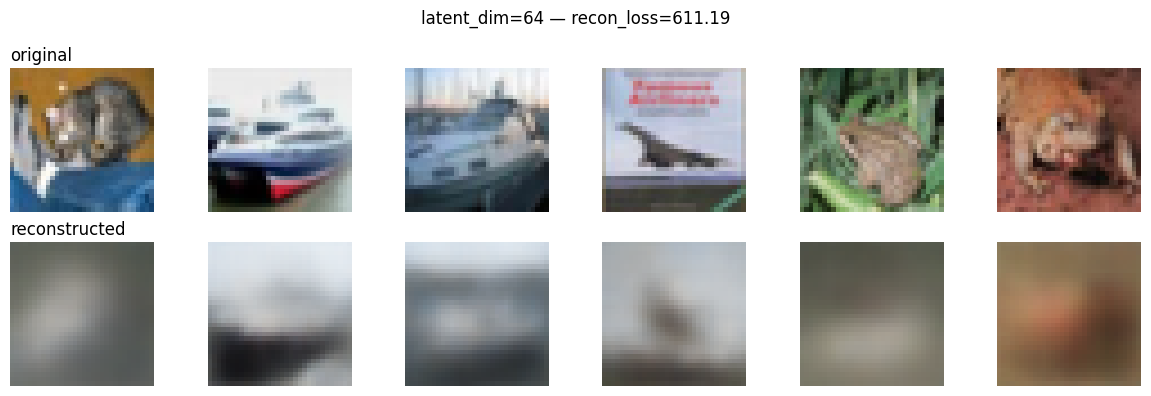


Training latent_dim=128
Final -> total: 626.2575, recon: 612.2136, kl: 14.0440


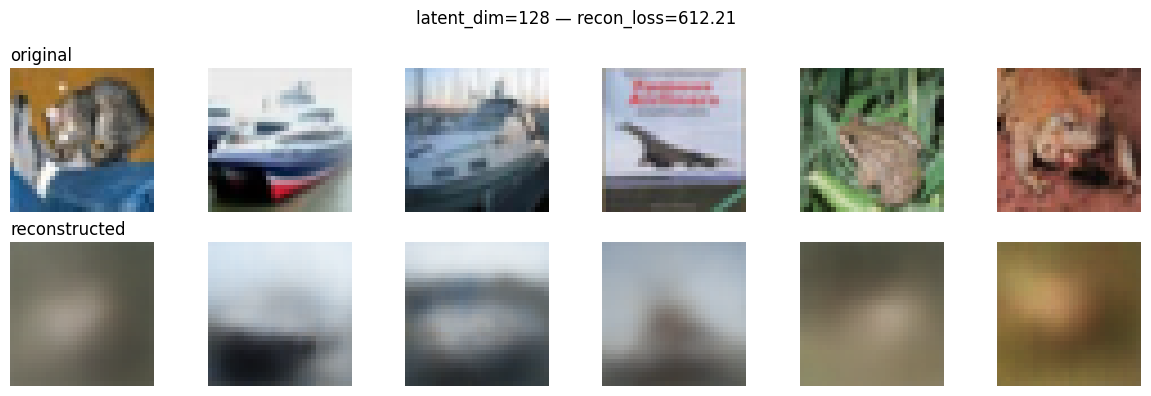



Summary (sorted by reconstruction loss, lower = better):
 latent_dim  final_total_loss  final_recon_loss  final_kl_loss
         32        624.459534        609.609375      14.849952
         16        624.930847        610.318909      14.611938
         64        625.441040        611.188721      14.252061
        128        626.257507        612.213623      14.043977


In [15]:
import itertools
import pandas as pd

# ---------- VAE model (binary_crossentropy reconstruction) ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Sweep setup ----------
latent_dims = [16, 32, 64, 128]
batch_size = 128
epochs = 50   # kept lower for the sweep since 4 runs at 100 would take very long; retrain winner at 100 after

def build_vae(latent_dim):
    encoder_inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
    x = layers.Reshape((2, 2, 512))(x)
    x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae

results = []
n_show = 6
sample_imgs = X_test_norm[:n_show]

for ldim in latent_dims:
    print(f"\n{'='*50}")
    print(f"Training latent_dim={ldim}")
    print(f"{'='*50}")

    vae = build_vae(ldim)
    history = vae.fit(X_train_norm, epochs=epochs, batch_size=batch_size, verbose=0)

    final_recon = history.history['reconstruction_loss'][-1]
    final_kl = history.history['kl_loss'][-1]
    final_total = history.history['loss'][-1]
    results.append({
        "latent_dim": ldim,
        "final_total_loss": final_total,
        "final_recon_loss": final_recon,
        "final_kl_loss": final_kl,
    })
    print(f"Final -> total: {final_total:.4f}, recon: {final_recon:.4f}, kl: {final_kl:.4f}")

    _, _, z = vae.encoder.predict(sample_imgs, verbose=0)
    reconstructed = vae.decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
    for i in range(n_show):
        axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
    axes[0, 0].set_title("original", loc='left')
    axes[1, 0].set_title("reconstructed", loc='left')
    plt.suptitle(f"latent_dim={ldim} — recon_loss={final_recon:.2f}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("final_recon_loss")
print("\n\nSummary (sorted by reconstruction loss, lower = better):")
print(results_df.to_string(index=False))


Training loss_type=bce
Final -> total: 624.7309, recon: 610.0104, kl: 14.7206


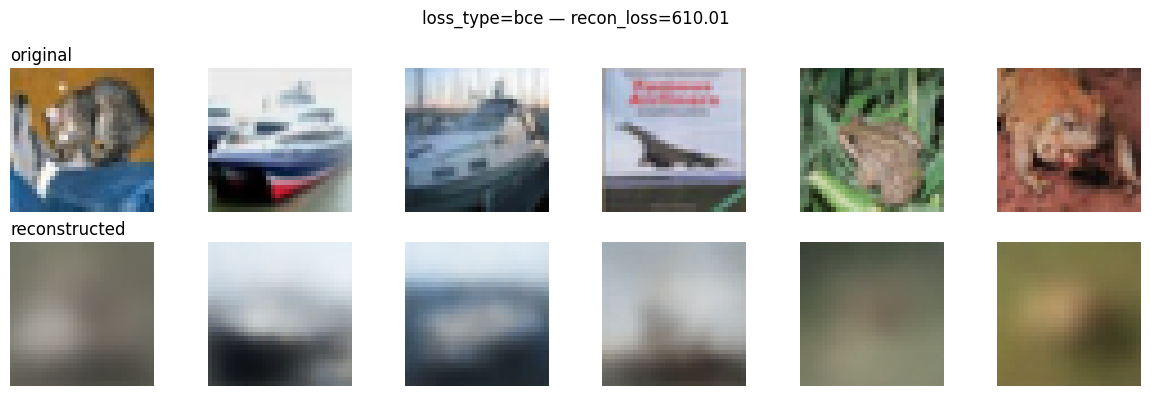


Training loss_type=mse
Final -> total: 34.0864, recon: 26.0100, kl: 8.0765


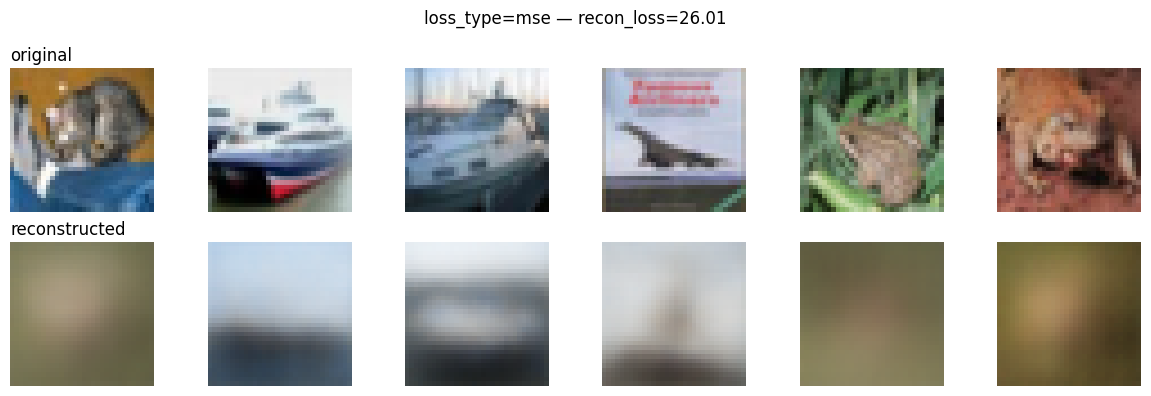


Training loss_type=mae
Final -> total: 120.1487, recon: 103.4683, kl: 16.6805


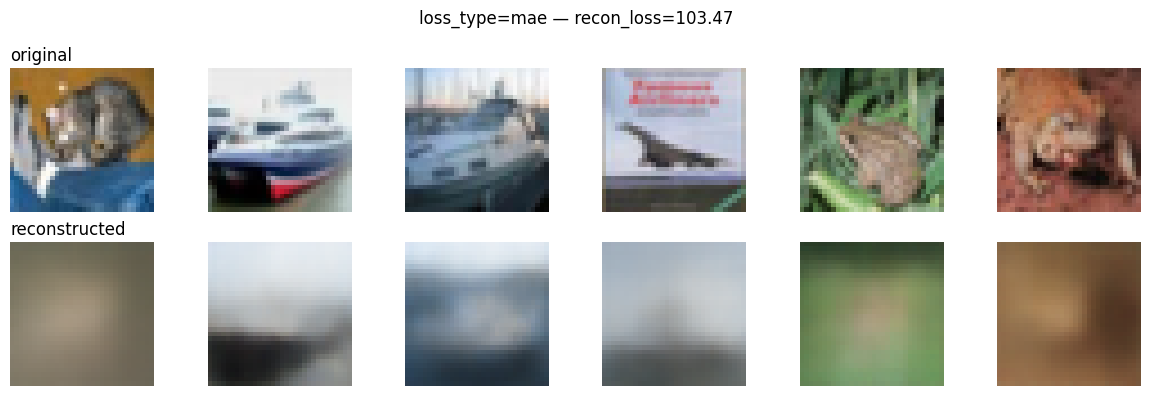



Summary (note: recon_loss NOT directly comparable across loss types — judge visually too):
loss_type  final_total_loss  final_recon_loss  final_kl_loss
      bce        624.730896        610.010437      14.720613
      mse         34.086449         26.009974       8.076478
      mae        120.148689        103.468277      16.680468


In [17]:
import pandas as pd

# ---------- VAE model with selectable loss function ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type="bce", beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def compute_reconstruction_loss(self, data, reconstruction):
        if self.loss_type == "bce":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mse":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mae":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_absolute_error(data, reconstruction), axis=(1, 2))
            )
        else:
            raise ValueError(f"Unknown loss_type: {self.loss_type}")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.compute_reconstruction_loss(data, reconstruction)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Sweep setup ----------
loss_types = ["bce", "mse", "mae"]
latent_dim = 32
batch_size = 128
epochs = 50   # per-combo epochs for the sweep; retrain the winner longer afterwards

def build_vae(loss_type):
    encoder_inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
    x = layers.Reshape((2, 2, 512))(x)
    x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

    vae = VAE(encoder, decoder, loss_type=loss_type, beta=1.0)
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae

results = []
n_show = 6
sample_imgs = X_test_norm[:n_show]

for loss_type in loss_types:
    print(f"\n{'='*50}")
    print(f"Training loss_type={loss_type}")
    print(f"{'='*50}")

    vae = build_vae(loss_type)
    history = vae.fit(X_train_norm, epochs=epochs, batch_size=batch_size, verbose=0)

    final_recon = history.history['reconstruction_loss'][-1]
    final_kl = history.history['kl_loss'][-1]
    final_total = history.history['loss'][-1]
    results.append({
        "loss_type": loss_type,
        "final_total_loss": final_total,
        "final_recon_loss": final_recon,
        "final_kl_loss": final_kl,
    })
    print(f"Final -> total: {final_total:.4f}, recon: {final_recon:.4f}, kl: {final_kl:.4f}")

    _, _, z = vae.encoder.predict(sample_imgs, verbose=0)
    reconstructed = vae.decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
    for i in range(n_show):
        axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
    axes[0, 0].set_title("original", loc='left')
    axes[1, 0].set_title("reconstructed", loc='left')
    plt.suptitle(f"loss_type={loss_type} — recon_loss={final_recon:.2f}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
print("\n\nSummary (note: recon_loss NOT directly comparable across loss types — judge visually too):")
print(results_df.to_string(index=False))


Training bce + 30% ssim
Final -> total: 442.4497, recon: 430.6617, kl: 11.7879


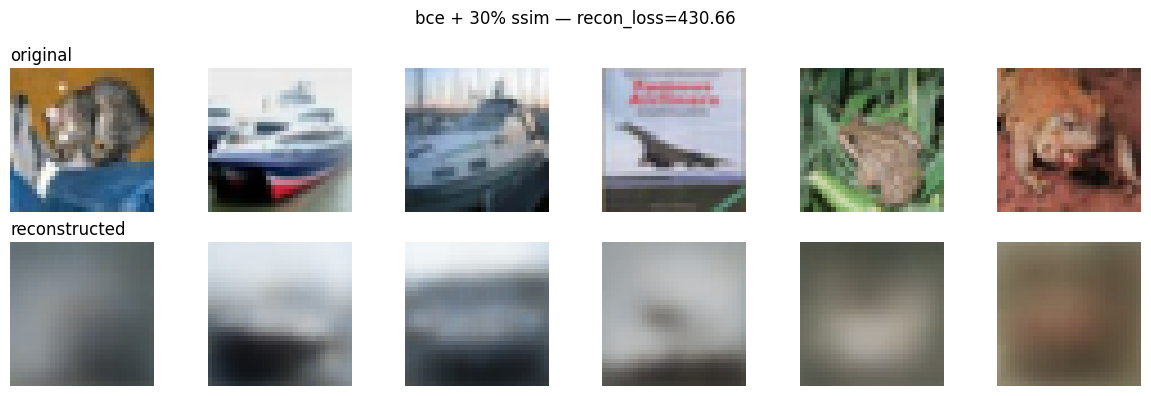


Training mae + 50% ssim
Final -> total: 69.0828, recon: 58.9628, kl: 10.1200


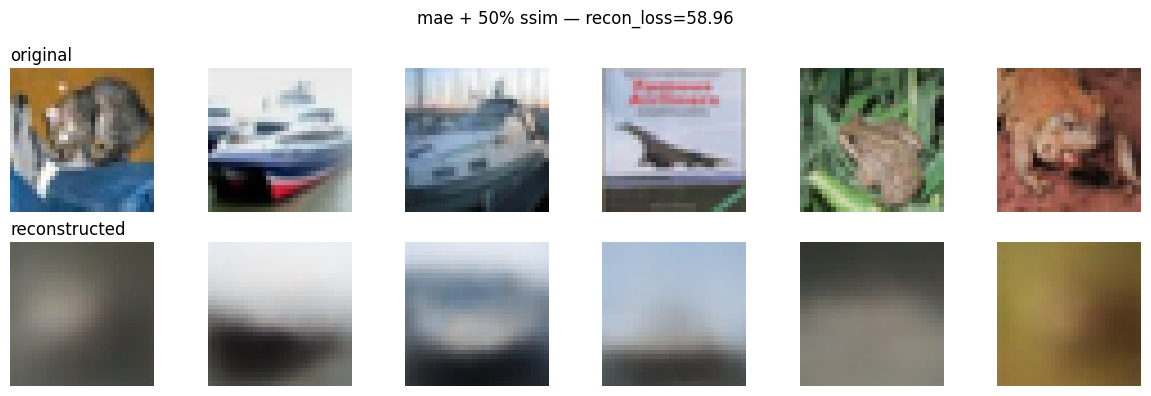


Training mse + 50% ssim
Final -> total: 20.9652, recon: 16.6315, kl: 4.3337


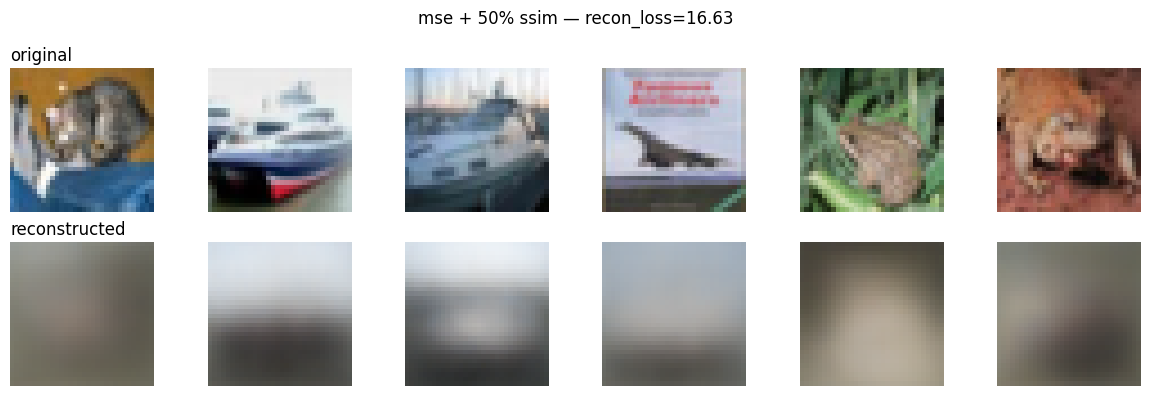



Summary (recon_loss scale differs by combo — compare visually too):
         combo  final_total_loss  final_recon_loss  final_kl_loss
bce + 30% ssim        442.449677        430.661652      11.787872
mae + 50% ssim         69.082848         58.962826      10.119981
mse + 50% ssim         20.965168         16.631498       4.333675


In [19]:
import pandas as pd

# ---------- VAE model with hybrid loss support ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type="bce", ssim_weight=0.0, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type      # base pixel loss: "bce", "mse", or "mae"
        self.ssim_weight = ssim_weight  # how much SSIM to blend in (0.0 = pure pixel loss, 1.0 = pure ssim)
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def pixel_loss(self, data, reconstruction):
        if self.loss_type == "bce":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mse":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mae":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_absolute_error(data, reconstruction), axis=(1, 2))
            )
        else:
            raise ValueError(f"Unknown loss_type: {self.loss_type}")

    def compute_reconstruction_loss(self, data, reconstruction):
        px_loss = self.pixel_loss(data, reconstruction)
        if self.ssim_weight > 0:
            ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(data, reconstruction, max_val=1.0))
            return (1 - self.ssim_weight) * px_loss + self.ssim_weight * ssim_loss
        return px_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.compute_reconstruction_loss(data, reconstruction)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Sweep setup: hybrid combos ----------
# (loss_type, ssim_weight) — ssim_weight=0.0 means pure pixel loss, no hybrid
hybrid_combos = [
    ("bce", 0.3),   # 70% bce + 30% ssim
    ("mae", 0.5),   # 50/50 mae + ssim
    ("mse", 0.5),   # 50/50 mse + ssim
]

latent_dim = 32
batch_size = 128
epochs = 50

def build_vae(loss_type, ssim_weight):
    encoder_inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
    x = layers.Reshape((2, 2, 512))(x)
    x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

    vae = VAE(encoder, decoder, loss_type=loss_type, ssim_weight=ssim_weight, beta=1.0)
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae

results = []
n_show = 6
sample_imgs = X_test_norm[:n_show]

for loss_type, ssim_weight in hybrid_combos:
    label = f"{loss_type} + {ssim_weight*100:.0f}% ssim" if ssim_weight > 0 else f"pure {loss_type}"
    print(f"\n{'='*50}")
    print(f"Training {label}")
    print(f"{'='*50}")

    vae = build_vae(loss_type, ssim_weight)
    history = vae.fit(X_train_norm, epochs=epochs, batch_size=batch_size, verbose=0)

    final_recon = history.history['reconstruction_loss'][-1]
    final_kl = history.history['kl_loss'][-1]
    final_total = history.history['loss'][-1]
    results.append({
        "combo": label,
        "final_total_loss": final_total,
        "final_recon_loss": final_recon,
        "final_kl_loss": final_kl,
    })
    print(f"Final -> total: {final_total:.4f}, recon: {final_recon:.4f}, kl: {final_kl:.4f}")

    _, _, z = vae.encoder.predict(sample_imgs, verbose=0)
    reconstructed = vae.decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
    for i in range(n_show):
        axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
    axes[0, 0].set_title("original", loc='left')
    axes[1, 0].set_title("reconstructed", loc='left')
    plt.suptitle(f"{label} — recon_loss={final_recon:.2f}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
print("\n\nSummary (recon_loss scale differs by combo — compare visually too):")
print(results_df.to_string(index=False))


Training bce + 30% ssim, beta=0.001
Final -> total: 408.4821, recon: 408.3396, kl: 142.1942


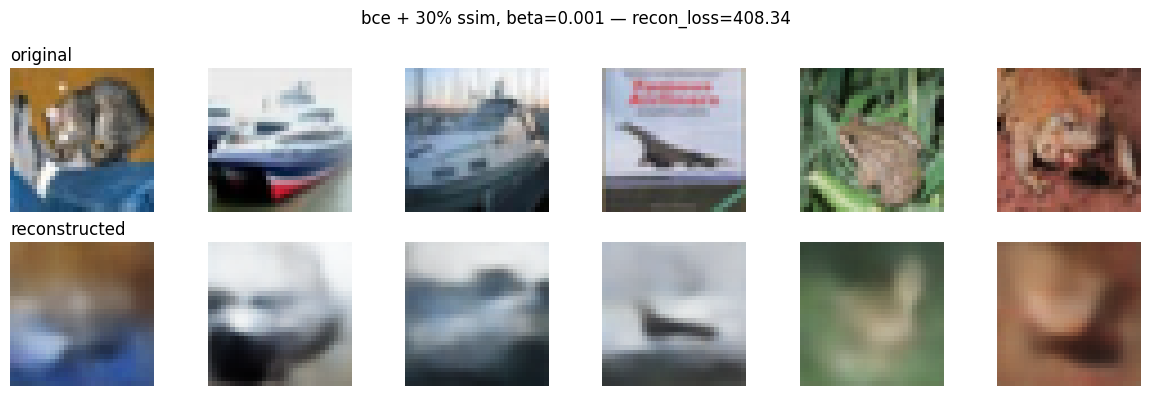


Training mae + 50% ssim, beta=0.001
Final -> total: 34.6892, recon: 34.5413, kl: 147.9010


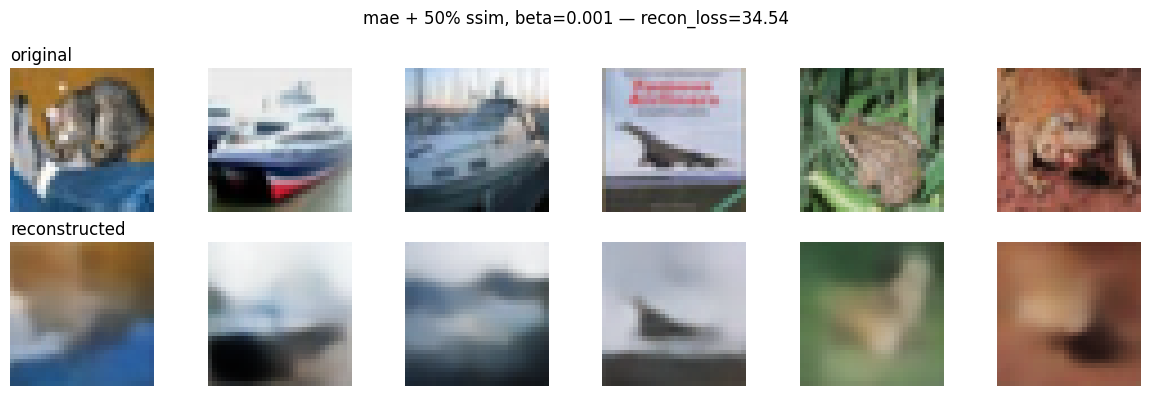


Training mse + 50% ssim, beta=0.001
Final -> total: 5.0169, recon: 4.8993, kl: 117.6059


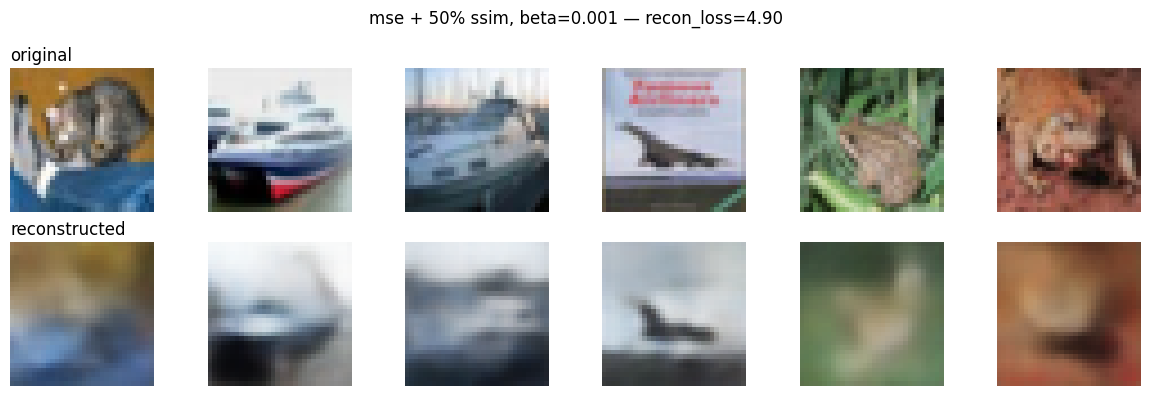



Summary (recon_loss scale differs by combo — compare visually too):
                     combo  final_total_loss  final_recon_loss  final_kl_loss
bce + 30% ssim, beta=0.001        408.482056        408.339600     142.194244
mae + 50% ssim, beta=0.001         34.689209         34.541298     147.900955
mse + 50% ssim, beta=0.001          5.016911          4.899302     117.605888


In [20]:
import pandas as pd

# ---------- VAE model with hybrid loss + beta-weighted KL ----------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type="bce", ssim_weight=0.0, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        self.ssim_weight = ssim_weight
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def pixel_loss(self, data, reconstruction):
        if self.loss_type == "bce":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mse":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1, 2))
            )
        elif self.loss_type == "mae":
            return tf.reduce_mean(
                tf.reduce_sum(keras.losses.mean_absolute_error(data, reconstruction), axis=(1, 2))
            )
        else:
            raise ValueError(f"Unknown loss_type: {self.loss_type}")

    def compute_reconstruction_loss(self, data, reconstruction):
        px_loss = self.pixel_loss(data, reconstruction)
        if self.ssim_weight > 0:
            ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(data, reconstruction, max_val=1.0))
            return (1 - self.ssim_weight) * px_loss + self.ssim_weight * ssim_loss
        return px_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.compute_reconstruction_loss(data, reconstruction)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Sweep setup: hybrid combos, now with beta=0.001 ----------
hybrid_combos = [
    ("bce", 0.3),
    ("mae", 0.5),
    ("mse", 0.5),
]

latent_dim = 32
batch_size = 128
epochs = 50
beta = 0.001   # loosened KL constraint, applied to all combos this run

def build_vae(loss_type, ssim_weight, beta):
    encoder_inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
    x = layers.Reshape((2, 2, 512))(x)
    x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

    vae = VAE(encoder, decoder, loss_type=loss_type, ssim_weight=ssim_weight, beta=beta)
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae

results = []
n_show = 6
sample_imgs = X_test_norm[:n_show]

for loss_type, ssim_weight in hybrid_combos:
    label = f"{loss_type} + {ssim_weight*100:.0f}% ssim, beta={beta}"
    print(f"\n{'='*50}")
    print(f"Training {label}")
    print(f"{'='*50}")

    vae = build_vae(loss_type, ssim_weight, beta)
    history = vae.fit(X_train_norm, epochs=epochs, batch_size=batch_size, verbose=0)

    final_recon = history.history['reconstruction_loss'][-1]
    final_kl = history.history['kl_loss'][-1]
    final_total = history.history['loss'][-1]
    results.append({
        "combo": label,
        "final_total_loss": final_total,
        "final_recon_loss": final_recon,
        "final_kl_loss": final_kl,
    })
    print(f"Final -> total: {final_total:.4f}, recon: {final_recon:.4f}, kl: {final_kl:.4f}")

    _, _, z = vae.encoder.predict(sample_imgs, verbose=0)
    reconstructed = vae.decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 4))
    for i in range(n_show):
        axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
    axes[0, 0].set_title("original", loc='left')
    axes[1, 0].set_title("reconstructed", loc='left')
    plt.suptitle(f"{label} — recon_loss={final_recon:.2f}")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results)
print("\n\nSummary (recon_loss scale differs by combo — compare visually too):")
print(results_df.to_string(index=False))

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_41 (InputLayer)          [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_97 (Conv2D)             (None, 16, 16, 32)   896         ['input_41[0][0]']               
                                                                                                  
 batch_normalization_180 (Batch  (None, 16, 16, 32)  128         ['conv2d_97[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation_180 (Activation)    (None, 16, 16, 32)   0           ['batch_normalization_180[0

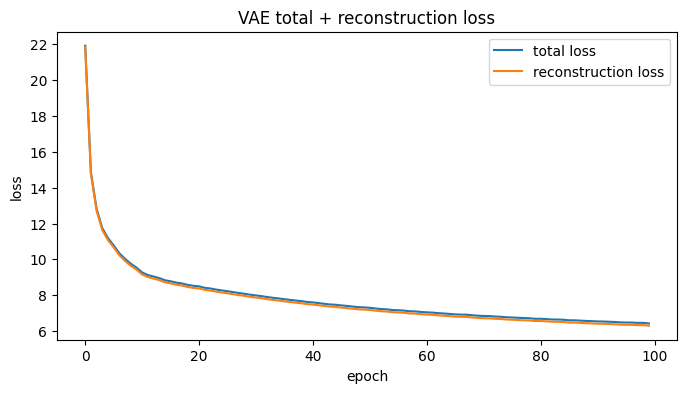

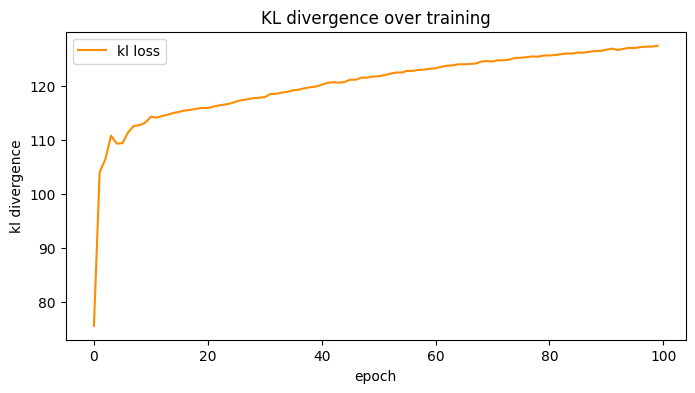

Final total loss: 6.4248
Final reconstruction loss: 6.2974
Final KL divergence: 127.3907


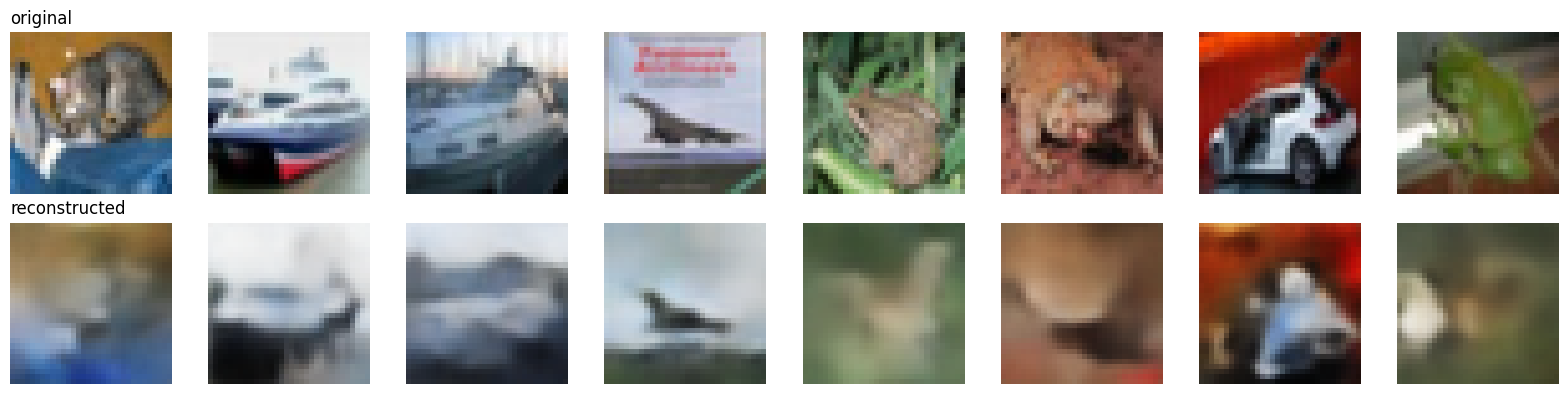

In [21]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type="mse", ssim_weight=0.5, edge_weight=10.0, beta=0.001, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        self.ssim_weight = ssim_weight
        self.edge_weight = edge_weight
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def pixel_loss(self, data, reconstruction):
        return tf.reduce_mean(
            tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1, 2))
        )

    def edge_loss(self, data, reconstruction):
        data_edges = tf.image.sobel_edges(data)
        recon_edges = tf.image.sobel_edges(reconstruction)
        return tf.reduce_mean(tf.abs(data_edges - recon_edges))

    def compute_reconstruction_loss(self, data, reconstruction):
        px_loss = self.pixel_loss(data, reconstruction)
        ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(data, reconstruction, max_val=1.0))
        total = (1 - self.ssim_weight) * px_loss + self.ssim_weight * ssim_loss

        edge = self.edge_loss(data, reconstruction)
        total = total + self.edge_weight * edge

        return total

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = self.compute_reconstruction_loss(data, reconstruction)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# ---------- Architecture ----------
latent_dim = 32

encoder_inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2D(512, 3, strides=1, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(2 * 2 * 512, activation="relu")(decoder_inputs)
x = layers.Reshape((2, 2, 512))(x)
x = layers.Conv2DTranspose(512, 3, strides=1, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()

# ---------- Data ----------
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# ---------- Train ----------
vae = VAE(encoder, decoder, loss_type="mse", ssim_weight=0.5, edge_weight=10.0, beta=0.001)
_ = vae(X_test_norm[:1])
vae.compile(optimizer=keras.optimizers.Adam())

checkpoint_path = "cvae_cifar10_mse_ssim50_edge_beta.weights.h5"
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor="loss",
    save_best_only=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint_cb]
)

# ---------- Curves ----------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='total loss')
plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('VAE total + reconstruction loss')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['kl_loss'], label='kl loss', color='darkorange')
plt.xlabel('epoch'); plt.ylabel('kl divergence'); plt.legend()
plt.title('KL divergence over training')
plt.show()

print(f"Final total loss: {history.history['loss'][-1]:.4f}")
print(f"Final reconstruction loss: {history.history['reconstruction_loss'][-1]:.4f}")
print(f"Final KL divergence: {history.history['kl_loss'][-1]:.4f}")

# ---------- Reconstructions ----------
vae.load_weights(checkpoint_path)

n = 8
sample_imgs = X_test_norm[:n]
_, _, z = vae.encoder.predict(sample_imgs, verbose=0)
reconstructed = vae.decoder.predict(z, verbose=0)

fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i]); axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
axes[0, 0].set_title("original", loc='left')
axes[1, 0].set_title("reconstructed", loc='left')
plt.tight_layout()
plt.show()